In [1]:
import numpy as np

import math
import torch

torch.set_default_dtype(torch.double)

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
def log_normal_pdf(x, m, s):
    return -0.5*torch.log(2*math.pi*s*s) - 0.5*((x - m)/s)**2

# Variational family: Normal N(m, s^2)
def elbo_estimate(m, log_s, log_p_fn, num_samples=2048):
    s = torch.exp(log_s)
    eps = torch.randn(num_samples, dtype=m.dtype)
    z   = m + s*eps
    lp  = log_p_fn(z)                        # log p(z)
    lq  = log_normal_pdf(z, m, s)            # log q(z)
    return (lp - lq).mean()

def fit_vi(log_p_fn, m_init=0.0, s_init=1.0, steps=2000, lr=0.05):
    m     = torch.tensor(m_init, requires_grad=True)
    log_s = torch.tensor(np.log(s_init), requires_grad=True)
    opt = torch.optim.Adam([m, log_s], lr=lr)

    for t in range(steps):
        opt.zero_grad()
        loss = -elbo_estimate(m, log_s, log_p_fn, num_samples=4096)
        loss.backward()
        opt.step()
    return m.detach().item(), torch.exp(log_s).detach().item()

In [6]:
# ----- Example 1: Mode-seeking (mixture posterior) -----
def log_p_mixture(x):
    logp1 = log_normal_pdf(x, torch.tensor(-3.), torch.tensor(0.5))
    logp2 = log_normal_pdf(x,  torch.tensor(3.), torch.tensor(0.5))
    # mixture log-sum-exp
    return torch.log(0.5*torch.exp(logp1) + 0.5*torch.exp(logp2))

m1, s1 = fit_vi(log_p_mixture, m_init=-1.0, s_init=1.0)

# ----- Example 2: Variance underestimation (wide Gaussian posterior) -----
def log_p_wide(x):
    return log_normal_pdf(x, torch.tensor(0.0), torch.tensor(3.0))

m2, s2 = fit_vi(log_p_wide, m_init=0.0, s_init=1.0)

# ----- Plot results -----
x = np.linspace(-10, 10, 1000)

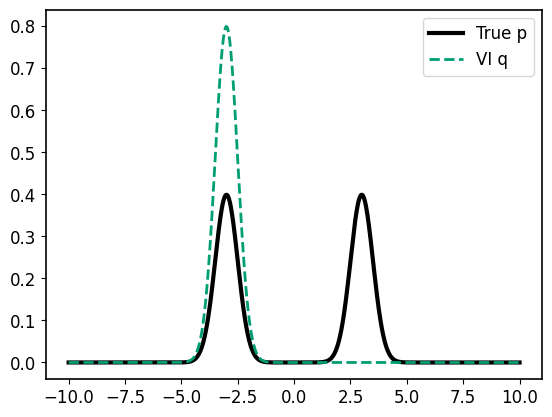

In [49]:
# Example 1
p1 = 0.5*torch.exp(log_normal_pdf(torch.tensor(x), torch.tensor(-3.), torch.tensor(0.5))) \
   + 0.5*torch.exp(log_normal_pdf(torch.tensor(x),  torch.tensor(3.), torch.tensor(0.5)))
q1 = torch.exp(log_normal_pdf(torch.tensor(x), torch.tensor(m1), torch.tensor(s1)))

plt.plot(x, p1, label="True p", color="k", lw=3)
plt.plot(x, q1, '--', label="VI q", color="C1", lw=2)
# plt.title("Example 1: Mode-seeking")
plt.legend()
plt.show()

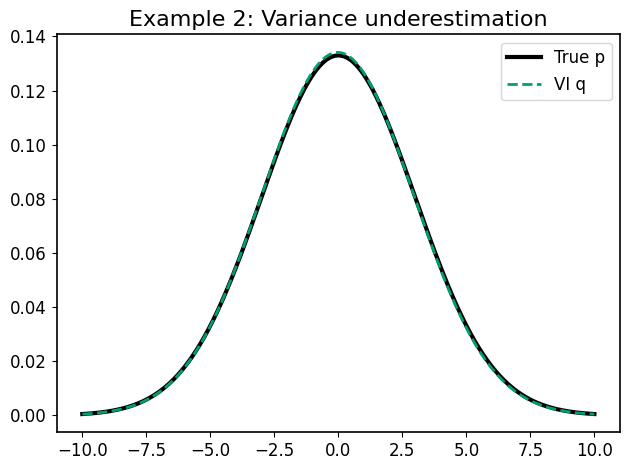

In [19]:
p2 = torch.exp(log_normal_pdf(torch.tensor(x), torch.tensor(0.), torch.tensor(3.)))
q2 = torch.exp(log_normal_pdf(torch.tensor(x), torch.tensor(m2), torch.tensor(s2)))

plt.plot(x, p2, label="True p", color="k", lw=3)
plt.plot(x, q2, '--', label="VI q", color="C1", lw=2)
plt.title("Example 2: Variance underestimation")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
rng = torch.Generator().manual_seed(0)

def log_mvn_pdf(x, mean, cov):
    """
    x: (N, d)
    mean: (d,)
    cov: (d,d) positive definite
    """
    d = mean.shape[0]
    L = torch.linalg.cholesky(cov)
    diff = x - mean
    # solve L y = diff^T => y = L^{-1} diff^T
    y = torch.cholesky_solve(diff.T, L)      # solves (L L^T) y = diff^T for y
    quad = (diff.T * y).sum(dim=0)           # diag(diff^T Σ^{-1} diff)
    logdet = 2.0*torch.log(torch.diag(L)).sum()
    return -0.5*(d*np.log(2*np.pi) + logdet + quad)

def elbo_estimate_2d(m_vec, log_s_vec, mean, cov, n=4096):
    """
    Mean-field q: z = m + s * eps with eps ~ N(0, I), elementwise mult.
    """
    s_vec = torch.exp(log_s_vec)
    eps = torch.randn(n, 2, generator=rng, dtype=m_vec.dtype)
    z   = m_vec + s_vec * eps
    lp  = log_mvn_pdf(z, mean, cov)
    lq  = log_normal_pdf(z[:,0], m_vec[0], s_vec[0]) + log_normal_pdf(z[:,1], m_vec[1], s_vec[1])
    return (lp - lq).mean()

def fit_vi_2d(mean, cov, m_init=(0.0, 0.0), s_init=(1.0, 1.0), steps=3000, lr=0.05):
    m_vec     = torch.tensor(m_init, requires_grad=True)
    log_s_vec = torch.tensor(np.log(s_init), requires_grad=True)
    opt = torch.optim.Adam([m_vec, log_s_vec], lr=lr)
    for t in range(steps):
        opt.zero_grad()
        loss = -elbo_estimate_2d(m_vec, log_s_vec, mean, cov, n=4096)
        loss.backward()
        opt.step()
    with torch.no_grad():
        m = m_vec.detach().numpy()
        s = torch.exp(log_s_vec).detach().numpy()
    return m, s

def kl_gauss(m0, S0, m1, S1):
    """
    KL(N0 || N1) with N0(mean m0, cov S0), N1(mean m1, cov S1)
    """
    d = m0.shape[0]
    S1_inv = np.linalg.inv(S1)
    diff = (m1 - m0).reshape(-1,1)
    term1 = np.trace(S1_inv @ S0)
    term2 = (diff.T @ S1_inv @ diff).item()
    term3 = -d
    term4 = np.log(np.linalg.det(S1)/np.linalg.det(S0))
    return 0.5*(term1 + term2 + term3 + term4)


In [23]:
mu_true = torch.zeros(2)
sigma1, sigma2, rho = 3.0, 1.5, 0.9
cov_true = torch.tensor([[sigma1**2, rho*sigma1*sigma2],
                         [rho*sigma1*sigma2, sigma2**2]], dtype=torch.float64)

m2, s2 = fit_vi_2d(mu_true, cov_true, m_init=(0.5, -0.5), s_init=(1.0, 1.0), steps=4000, lr=0.05)

# KL for example 2 (analytic)
S0 = np.diag(s2**2)                 # q covariance (diagonal)
S1 = cov_true.numpy()               # p covariance (full)
kl2 = kl_gauss(m2, S0, np.zeros(2), S1)

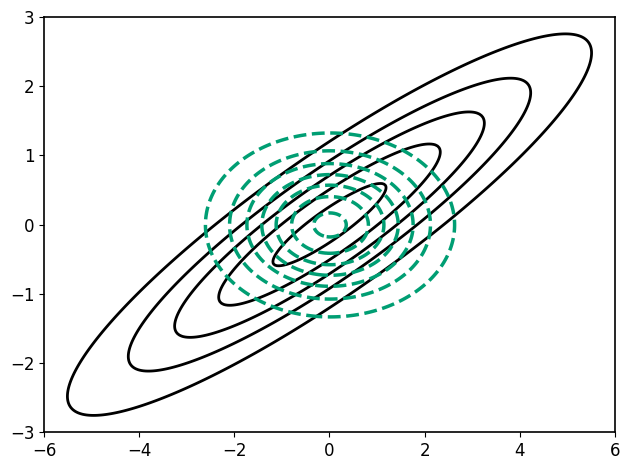

In [48]:
x1 = np.linspace(-6, 6, 300)
x2 = np.linspace(-3, 3, 300)
X1, X2 = np.meshgrid(x1, x2)
X = np.stack([X1, X2], axis=-1).reshape(-1, 2)
Xt = torch.tensor(X)

with torch.no_grad():
    logp = log_mvn_pdf(Xt, mu_true, cov_true).numpy().reshape(X1.shape)
    # q density: product of univariate normals with learned m2, s2
    m2_t = torch.tensor(m2)
    s2_t = torch.tensor(s2)
    logq = (log_normal_pdf(Xt[:,0], m2_t[0], s2_t[0]) +
            log_normal_pdf(Xt[:,1], m2_t[1], s2_t[1])).numpy().reshape(X1.shape)

# contour levels (same for both for fair visual)
levels = np.linspace(logp.max()-12, logp.max()-2, 7)

cs1 = plt.contour(X1, X2, np.exp(logp), linewidths=2, colors="k")
cs2 = plt.contour(X1, X2, np.exp(logq), linestyles="--", colors="C1")

# plt.clabel(cs1, inline=1, fontsize=8)
# plt.clabel(cs2, inline=1, fontsize=8)
# ax2.set_title("Example 2: Correlated posterior vs mean-field VI")
# ax2.set_xlabel(r"$\theta_1$"); ax2.set_ylabel(r"$\theta_2$")
# plt.legend([cs1.collections[0], cs2.collections[0]], ["True p(θ)", "VI q(θ) (diag)"], loc="upper right")

# plt.legend()
plt.tight_layout()
plt.show()